# 🌾 Частотный анализ лексических и этнографических диалектизмов в "Тихом Доне" М. А. Шолохова

**Цель:** на примере языковых единиц конкретных, тематически цельных глав "Тихого Дона" выявить две ведущие тенденции в романе, в частности, колорит казаческой жизни и описание первой мировой и гражданской войн.

**Исследовательский вопрос:** диалектные слова распределяются по произведению неравномерно, они концентрируются в эпизодах с событиями повседневной жизни казаков, однако их доля уменьшается, когда в повествование врываются масштабные события и лица не из казачьей среды. Создающие национальный колорит слова маркируют мирную жизнь и естевенный ход вещей.

**Гипотеза:** В главах "Тихого Дона", посвященных казачьему быту и жизни, диалектизмы преобладают, а в описании военных событий и их хода М. Шолохов использует в большей степени чистую русскую речь, за исключением диалогов.


**Анализируемые данные:**

Для анализа были выбраны три главы "Тихого Дона", наиболее значимые в контексте исследовательского вопроса:

1) **Книга 1. Часть 1. Глава II** (описание казаческого бытта, много диалектизмов и соответствующей лексики)

2) **Книга 2. Часть 5. Глава XV** (военные описания с уменьшением доли диалектизмов)

3) **Книга 4. Часть 8. Глава XVIII** (окончание, установление равновесия)

Каждая глава сохранена в виде отдельного файда формата .txt.

**План работы:**

1) Выбор, подготовка и загрузка исследуемых фрагментов текста.

2) Очистка и токенизация текста.

3) Анализ общих данных о частотности слов в главах для лучшего понимания глав.

4) Составление перечня диалектизмов и этнографизмов, их классификация.

5) Подсчет абсолютной и относиельной частот по главам, сравнение глав.

6) Анализ коллокаций

7) Подведение итогов

8) Оформление результатов в виде презентации



In [19]:
!pip install pymorphy3
%pip install natasha

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.4/34.4 MB 65.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 114.7 MB/s eta 0:00:00
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=5624782ff849c29863fe07df118d041e6162a629aecc1bd66ebcbdeccba625e9
  Stored in directory: /root/.cache/pip/wheels/1a/bf/a1/4cee4f7678c68c5875ca89eaccf460593539805c3906722228
Successfully built docopt


1) Подключение nltk для работы с NLP - Natural Language Processing (альтернативный вариант первого этапа)
2) Подключение объекта для хранения стоп-слов из пакета NLTK.Corpus
3) Подключение natasha для проведения лемматизации и токенизации
4) Подключение re для обработки регулярных выражений
5) Подключение Pymorphy для лемматизации (перевод слов в начальную форму, альтернативный вариант первого этапа)
6) Подключение collections для подсчета частоты
7) Подключение библиотек и загрузка из библиотек для визуализаций (matplotlib.pyplot, numpy, WordCloud, LinearSegmentedColormap)

In [83]:
import nltk
from nltk.corpus import stopwords
from natasha import Segmenter, Doc
from natasha import MorphVocab
from natasha import NewsMorphTagger, NewsNERTagger, NewsEmbedding
import re
import pymorphy3
import collections
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np
from wordcloud import WordCloud
from matplotlib.colors import LinearSegmentedColormap

**БЛОК 1: Очистка текста и лемматизация**

Загружаем стоп-слова в переменную stop_words (список)

In [41]:
nltk.download("stopwords")
stop_words = stopwords.words("russian")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Лемматизацию и токенизацию будем проводить через библиотеку natasha, которая изучалась на курсе

In [85]:
segmenter = Segmenter()
morph_vocab = MorphVocab()
emb = NewsEmbedding()
morph_tagger = NewsMorphTagger(emb)


def file_to_lemmas(file_name, file_name_out):
  with open(file_name, 'r', encoding='utf-8') as file:
            text = file.read()

  cleaned = re.sub(r'[^а-яёА-ЯЁa-zA-Z\s]', ' ', text.lower())
  clean_text = re.sub(r'\s+', ' ', cleaned).strip()

  doc = Doc(clean_text)
  doc.segment(segmenter)  # Токенизация
  doc.tag_morph(morph_tagger)  # Морфологический разбор

  for token in doc.tokens:
      token.lemmatize(morph_vocab)

  lemmas = []
  for token in doc.tokens:
    if token.lemma not in stop_words:
      lemmas.append(token.lemma)

  print(f'Лемматизированный текст включает {len(lemmas)} лемм')

  with open(file_name_out, 'w', encoding='utf-8') as file:
    for lemma in lemmas:
      file.write(lemma + '\n')

    return lemmas

lemmas_1 = file_to_lemmas('Chapter_1.txt', 'Chapter_1_result.txt')
lemmas_2 = file_to_lemmas('Chapter_2.txt', 'Chapter_2_result.txt')
lemmas_3 = file_to_lemmas('Chapter_3.txt', 'Chapter_3_result.txt')

Лемматизированный текст включает 1457 лемм
Лемматизированный текст включает 862 лемм
Лемматизированный текст включает 780 лемм


Итак, мы видим, что первая глава включает наибольшее число лемм. Это важно учитывать при интерпретации некоторых результатов.

Альтернативный вариант проведения этого этапа с спользованием nltk и pymorphy3:

```
def file_to_lemmas(file_name, file_name_out):

  with open(file_name, 'r', encoding='utf-8') as file:
    text = file.read()

  cleaned = re.sub(r'\W+', ' ', text.lower())
  tokens = cleaned.split()


  cleaned_tokens = []
  for token in tokens:
    if token not in stop_words:
      cleaned_tokens.append(token)

  morph = pymorphy3.MorphAnalyzer()
  lemmas = []
  for token in cleaned_tokens:
    lemma = morph.parse(token)[0].normal_form
    lemmas.append(lemma)

  print(f"Лемматизированный текст включает {len(lemmas)} лемм")

  with open(file_name_out, 'w', encoding='utf-8') as file:
    for lemma in lemmas:
      file.write(lemma + '\n')

  return lemmas

lemmas_1 = file_to_lemmas('Chapter_1.txt', 'Chapter_1_result.txt')
lemmas_2 = file_to_lemmas('Chapter_2.txt', 'Chapter_2_result.txt')
lemmas_3 = file_to_lemmas('Chapter_3.txt', 'Chapter_3_result.txt')
```

Алгоритм альтернативного варианта:

Загружаем файл, прочитываем в прочитать в переменную text весь текст из файла, убраем знаки препинания, переводим текст в нижний регистр

*Используем регулярное выражение: \W означает любой символ, не являющийся буквой, цифрой или подчеркиванием.Знак + означает, что подряд идущие такие символы считаются одной группой.*

Разбиваем текст на слова и делаем из одной строки список слов (переменная tokens - это список строк), удаляем стоп-слова, проводим лемматизацию (приводим слова в начальную форму), создаем список лемм.

**БЛОК 2: Общее рассмотрение исследуемых глав с помощью частотных слов**

Для начала подсчитываем частотнось всех слов в целом для каждой из глав:

In [81]:
counter_1 = collections.Counter(lemmas_1)
dict_counter_1 = dict(counter_1.items())
counter_2 = collections.Counter(lemmas_2)
dict_counter_2 = dict(counter_2.items())
counter_3 = collections.Counter(lemmas_3)
dict_counter_3 = dict(counter_3.items())
print('Самые популярные слова в главе про быт', counter_1.most_common(20))
print('Самые популярные слова в главе про войну', counter_2.most_common(20))
print('Самые популярные слова в главе из конца', counter_3.most_common(20))

Самые популярные слова в главе про быт [('григорий', 38), ('митька', 20), ('вода', 17), ('баркас', 13), ('старик', 11), ('глаз', 11), ('нога', 10), ('рука', 10), ('отец', 9), ('сазан', 9), ('пантелей', 8), ('прокофиевич', 8), ('конец', 7), ('удилище', 7), ('глядеть', 7), ('это', 7), ('голова', 7), ('алексей', 7), ('берег', 6), ('рыба', 6)]
Самые популярные слова в главе про войну [('каледин', 16), ('богаевский', 12), ('правительство', 8), ('власть', 7), ('член', 7), ('казачий', 6), ('окно', 6), ('донский', 5), ('отряд', 5), ('глаз', 5), ('лежать', 5), ('часть', 4), ('ревком', 4), ('передать', 4), ('совет', 4), ('область', 4), ('съезд', 4), ('рука', 4), ('добровольческий', 4), ('час', 4)]
Самые популярные слова в главе из конца [('григорий', 17), ('день', 8), ('хутор', 6), ('лес', 6), ('степь', 5), ('жизнь', 5), ('дубрава', 5), ('ночь', 5), ('земля', 4), ('ребёнок', 4), ('фомин', 4), ('жить', 4), ('дезертир', 4), ('землянка', 4), ('часто', 4), ('родный', 4), ('это', 4), ('рука', 4), ('ч

Чтобы это визуализировать, решили построить облака слов для каждой из исследуемых глав. Для начала создаем общий алгоритм для них всех:

In [76]:
colors = ['#88011c', '#ef3320', '#d58d6b', '#a57f56', '#998f95']
custom_cmap = LinearSegmentedColormap.from_list('custom', colors)

def clouds(dict_counter, name):
  wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap=custom_cmap,
    max_words=100,
    random_state=42
  ).generate_from_frequencies(dict_counter)

  plt.figure(figsize=(12, 6))
  plt.imshow(wordcloud)
  plt.axis('off')
  plt.title(f'Облако наиболее частотных лемм в {name}:', fontsize=16)
  plt.show()

Непосредственно строим облака слов:

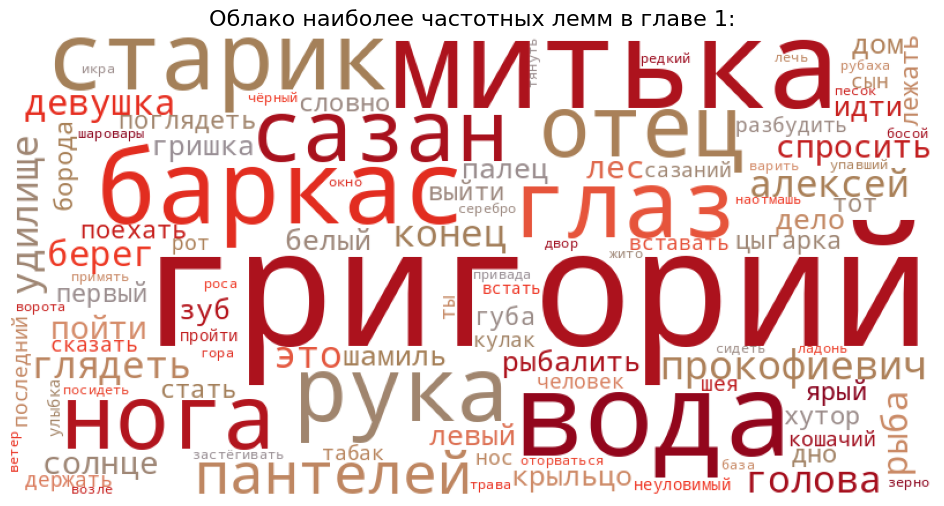

In [103]:
clouds(dict_counter_1, 'главе 1')

Картина самых частотных слов подтверждает правильный выбор главы. Она концентрируется на быте, повседневности и спокойном ходе мирной жизни.
В топе имена конкретных героев(Григорий, Митька, Пантелей), части тела (рука, нога, голова, палец) (это указывает на вещественнность, описания повседневности с фокусом на действиях и картине мира), родственные связи (отец, сын).

Все создает общую картину спокойного сельского быта. Тут даже вырисовывется целый пейзаж (дом, крыльцо, ворота, вода, солнце, берег).


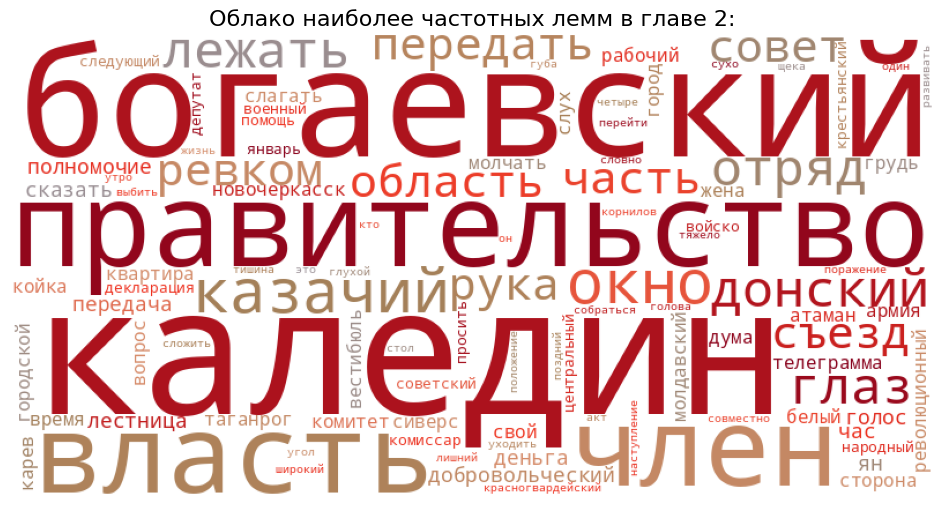

In [102]:
clouds(dict_counter_2, 'главе 2')

Тут картина чстотных слов заметно иная. Преобладают политические и близкие к этой теме слова (власть, депутат, полномочие, комиссар, область и т. д.). Частотные персонажи тоже соответствуют специфике (Каледин, Карев).

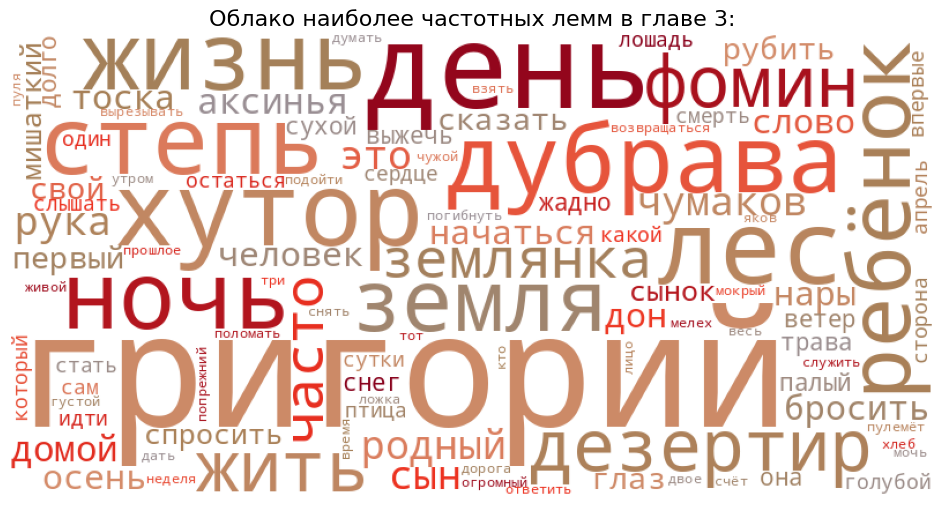

In [104]:
clouds(dict_counter_3, 'главе 3')

Третья глава, как и ожидалось, представляет баланс. В ней уже нет бытового спокойного набора первой из глав, но отсутствует и политичиность, масштабность второй из глав. Тут есть и слова военной темы (дезертир, служить), есть и пейзажные термины, хотя и более масштабные (лес, степь, Дон). Создается общая амосфера дороги, соединения настоящего и прошлого, уравнивающей все судьбы.

**БЛОК 3: Диалектный анализ**

Тут осуществляем следующие этапы:

1) Загружаем спсок диалектизмов

2) Сопоставляем все диалектизмы с частотным словарем для каждого текста и получаем количества вхождений каждого диалектизма в каждый текст

3) Скачиваем всю статистику в общий файл и выводим список диалектизмов появляющихся хоть в одном файле

In [48]:
# загрузка диалектизмов
dialects = []
with open("dialectisms.txt", 'r', encoding='utf-8') as file:
  for line in file:
    dialects.append(line.strip())

dialect_counts = []
file_name_out = "Диалектный анализ.txt"
#открыть файл на запись
with open(file_name_out, 'w', encoding='utf-8') as file:
  for dialect in dialects:
    if dialect in dict_counter_1:
      count1 = dict_counter_1[dialect]
    else:
      count1 = 0
    if dialect in dict_counter_2:
      count2 = dict_counter_2[dialect]
    else:
      count2 = 0
    if dialect in dict_counter_3:
      count3 = dict_counter_3[dialect]
    else:
      count3 = 0
    file.write(dialect + ' ' + str(count1) + ' ' + str(count2) + ' ' + str(count3) + '\n')
    dialect_counts.append((dialect, count1, count2, count3))
    if count1 != 0 or count2 != 0 or count3 != 0:
      print(dialect, count1, count2, count3)


бродить 0 0 1
ендова 1 0 0
зараз 0 0 1
коловерть 1 0 0
курень 1 0 0
маю 0 0 1
пал 0 0 1
скло 1 0 0
ссучить 1 0 0
стремя 1 0 0
татарник 0 0 1
травянка 1 0 0
чернобыл 0 0 1
яр 1 0 0


Преобладание диалектизмов в первой и третьей главах отражает их предметно-содержательный план: это описание казачьего быта, человеческих взаимоотношений, промыслов, например, в главе 1 персонаж Григорий с отцом удит рыбу и выслушивает наставление отца о запретной любви к Аксинье - жене соседа Степана, затем в канве повествования появляется купец Мохов, житель хутора и друг Григория Митька Коршунов, с которым они обсуждают дочь зажиточного купца. Глава 3 подводит итог этапу судьбы Григория и одновременно открывает перед ним новый горизонт - он хоронит любимую Аксинью, общается с сыном, в этих эпизодах возникают темы человеческого горя и внезапно вспыхнувшей надежды, принятия жизненного пути.

Отсутствие диалектизмов в описании военных событий и ходе истории связано со стремлением автора масштабировать трагедию, потому что катаклизмы затронули не только казачество и его цельный мир (первая мировая и гражданская войны), но и другие земли: так автор переходит от локального к общему, что ставит его наряду с Л.Н. Толстым и романом "Война и мир". Даже в конкретных военных эпизодах, как в главе 2 (смерть "белого" генерала Чернецова, самоубийство Каледина) эта идея выражена довольно четко


**БЛОК 4: Частотный анализ диалектизмов**

In [56]:
total_words_1 = len(lemmas_1)
total_words_2 = len(lemmas_2)
total_words_3 = len(lemmas_3)

print(f"Общее количество слов в главе 1: {total_words_1}")
print(f"Общее количество слов в главе 2: {total_words_2}")
print(f"Общее количество слов в главе 3: {total_words_3}")

total_abs_1 = 0
total_abs_2 = 0
total_abs_3 = 0

dialect_freqs = []
for dialect, c1, c2, c3 in dialect_counts:
    total_abs_1 += c1
    total_abs_2 += c2
    total_abs_3 += c3

    if total_words_1 > 0:
      rel_freq_1 = (c1 / total_words_1) * 1000 if total_words_1 > 0 else 0
    else:
      rel_freq_1 = 0
    if total_words_2 > 0:
      rel_freq_2 = (c2 / total_words_2) * 1000
    else:
      rel_freq_2 = 0
    if total_words_3 > 0:
      rel_freq_3 = (c3 / total_words_3) * 1000
    else:
      rel_freq_3 = 0

    dialect_freqs.append((dialect, c1, c2, c3, rel_freq_1, rel_freq_2, rel_freq_3))

print(f"\nАбсолютное количество диалектизмов:")
print(f"Глава 1: {total_abs_1}")
print(f"Глава 2: {total_abs_2}")
print(f"Глава 3: {total_abs_3}")

rel_total_1 = (total_abs_1 / total_words_1) * 1000
rel_total_2 = (total_abs_2 / total_words_2) * 1000
rel_total_3 = (total_abs_3 / total_words_3) * 1000

print(f"\nОтносительная частота диалектизмов (на 1000 слов):")
print(f"Глава 1: {rel_total_1:.2f}")
print(f"Глава 2: {rel_total_2:.2f}")
print(f"Глава 3: {rel_total_3:.2f}")

print()
print(f"{'Слово':<20} {'Глава 1 (абс)':<15} {'Глава 2 (абс)':<15} {'Глава 3 (абс)':<15} {'Глава 1 (на 1000)':<15} {'Глава 2 (на 1000)':<15} {'Глава 3 (на 1000)':<15}")

for dialect, c1, c2, c3, rf1, rf2, rf3 in dialect_freqs:
    if c1 > 0 or c2 > 0 or c3 > 0:
        print(f"{dialect:<20} {c1:>14} {c2:>14} {c3:>14} {rf1:>14.2f} {rf2:>14.2f} {rf3:>14.2f}")


Общее количество слов в главе 1: 1479
Общее количество слов в главе 2: 884
Общее количество слов в главе 3: 790

Абсолютное количество диалектизмов:
Глава 1: 8
Глава 2: 0
Глава 3: 6

Относительная частота диалектизмов (на 1000 слов):
Глава 1: 5.41
Глава 2: 0.00
Глава 3: 7.59

Слово                Глава 1 (абс)   Глава 2 (абс)   Глава 3 (абс)   Глава 1 (на 1000) Глава 2 (на 1000) Глава 3 (на 1000)
бродить                           0              0              1           0.00           0.00           1.27
ендова                            1              0              0           0.68           0.00           0.00
зараз                             0              0              1           0.00           0.00           1.27
коловерть                         1              0              0           0.68           0.00           0.00
курень                            1              0              0           0.68           0.00           0.00
маю                               0          

Для визуализации строим графики по абсолютной и относительной частотностям:

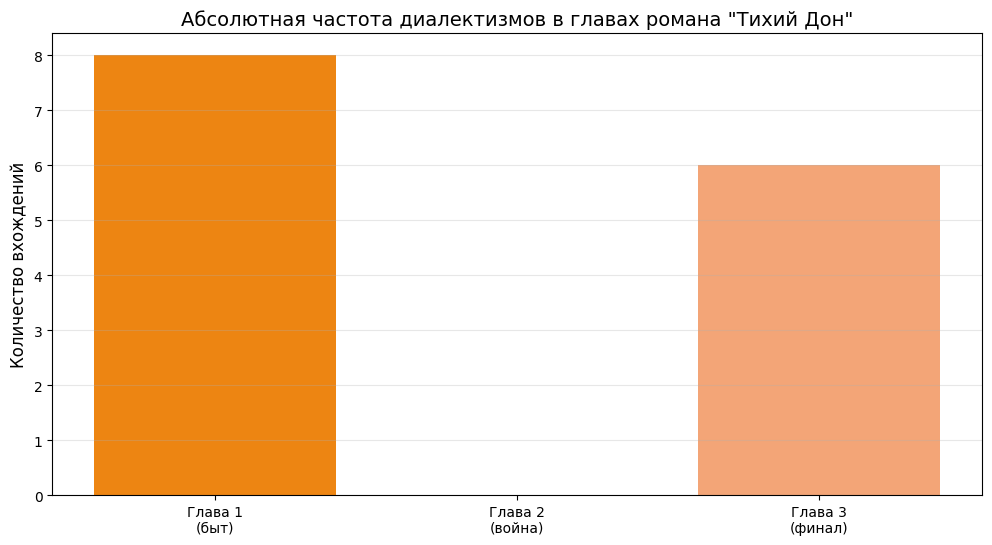

In [63]:
plt.figure(figsize=(12, 6))

chapters = ['Глава 1\n(быт)', 'Глава 2\n(война)', 'Глава 3\n(финал)']
abs_counts = [total_abs_1, total_abs_2, total_abs_3]
bars = plt.bar(chapters, abs_counts, color=['#ed8512', '#7d7d82', '#f3a577'])
plt.title('Абсолютная частота диалектизмов в главах романа "Тихий Дон"', fontsize=14)
plt.ylabel('Количество вхождений', fontsize=12)

plt.grid(axis='y', alpha=0.3)

plt.show()


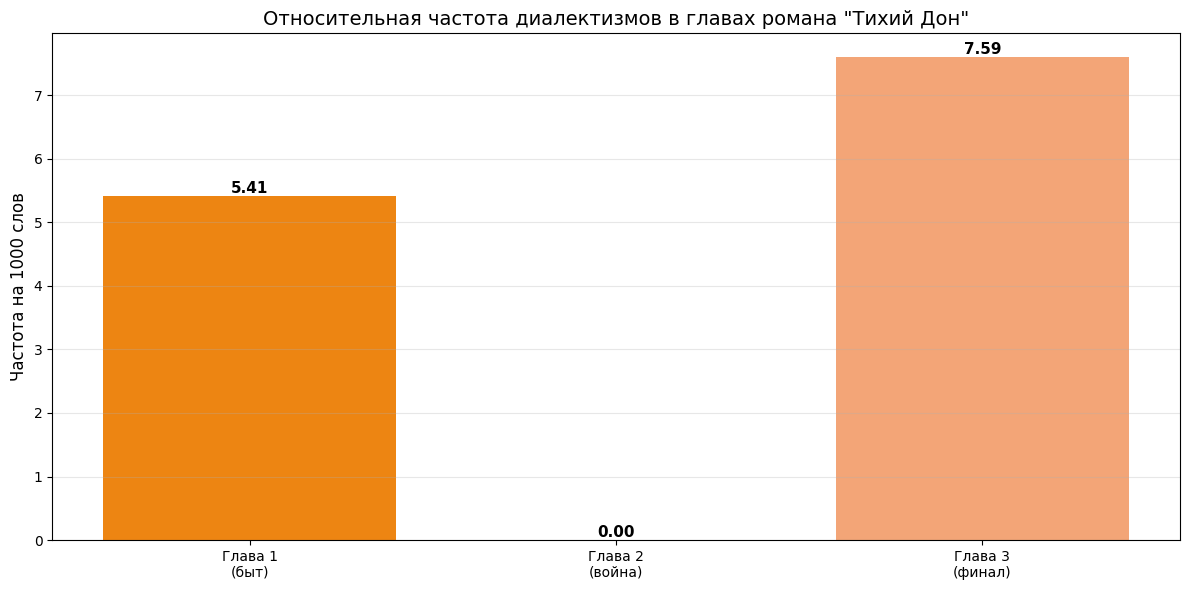

In [64]:
plt.figure(figsize=(12, 6))

chapters = ['Глава 1\n(быт)', 'Глава 2\n(война)', 'Глава 3\n(финал)']
rel_counts = [rel_total_1, rel_total_2, rel_total_3]
bars = plt.bar(chapters, rel_counts, color=['#ed8512', '#7d7d82', '#f3a577'])
plt.title('Относительная частота диалектизмов в главах романа "Тихий Дон"', fontsize=14)
plt.ylabel('Частота на 1000 слов', fontsize=12)

plt.grid(axis='y', alpha=0.3)

# Добавляем значения над столбцами с двумя знаками после запятой
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

Итак, мы видим, что во второй из глав диалектизмы полностью отсутствуют. Это подтверждает нашу гипотезу. Ее также подтверждает и тот факт, что в первой из глав абсолютная частотность выше, чем в третьей из них. Так, в наибольшей степени диалектизмы конценрируются в главе с описаниями быта, в меньшей степени, но представлены они в главе финала, а во второй главе они полностью отсутствуют.
 Важно, что относительная частотность при этом выше в третьей из глав. Можно сделать вывод, что в ней диалектизмы более концентрированы, в то время как в первой они более рассеяны. Это соответствует общим образам глав. В первой из них диалектизмы естественная часть повествования, составляющая общего колорита. В третьей же из глав они более концентрированы и специфичны в своем появлении в национально расшиенном пространстве и изменившемся после исторических событий мире. Необходимо, также отметить, что на этот результат мог повлиять и тот факт, что перая из глав самая большая.

**БЛОК 5: Разбор коллокаций для исследуемых диалектизмов**

Важно, что для коллакаций мы используем леммы, с токенами ряд диалектов не был найден в тексте

In [98]:
def get_collocations_from_lemmas_with_debug(lemmas_list, dialects, window_size=3, debug=False):
    collocations = defaultdict(lambda: defaultdict(int))
    found_dialects = set()

    for i, lemma in enumerate(lemmas_list):
        if lemma in dialects:
            found_dialects.add(lemma)
            start = max(0, i - window_size)
            end = min(len(lemmas_list), i + window_size + 1)

            for j in range(start, end):
                if j != i:
                    collocations[lemma][lemmas_list[j]] += 1

    return collocations

collocations_1 = get_collocations_from_lemmas_with_debug(lemmas_1, dialects)
collocations_2 = get_collocations_from_lemmas_with_debug(lemmas_2, dialects)
collocations_3 = get_collocations_from_lemmas_with_debug(lemmas_3, dialects)

In [100]:
for dialect, colloc in collocations_1.items():
    sorted_colloc = sorted(colloc.items(), key=lambda x: x[1], reverse=True)[:5]
    print(f"\n{dialect}:")
    for word, count in sorted_colloc:
        print(f"  {word}: {count} раз")


ендова:
  левобережный: 1 раз
  обдонья: 1 раз
  песок: 1 раз
  камышистый: 1 раз
  непролазить: 1 раз

курень:
  томиться: 1 раз
  солнце: 1 раз
  мелеховский: 1 раз
  первый: 1 раз
  оторваться: 1 раз

яр:
  черный: 2 раз
  баркас: 1 раз
  править: 1 раз
  спробуй: 1 раз
  возле: 1 раз

стремя:
  вода: 1 раз
  оторваться: 1 раз
  берег: 1 раз
  понести: 1 раз
  покачивая: 1 раз

коловерть:
  затонуть: 1 раз
  вяз: 1 раз
  вокруг: 1 раз
  гоняла: 1 раз
  бурый: 1 раз

серники:
  дело: 1 раз
  месяц: 1 раз
  ущерб: 1 раз
  захватить: 1 раз
  ага: 1 раз

травянка:
  особенно: 1 раз
  особенный: 1 раз
  тыква: 1 раз
  величина: 1 раз
  случиться: 1 раз

скло:
  гля: 1 раз
  гришка: 1 раз
  юбка: 1 раз
  насквозь: 1 раз
  весь: 1 раз


In [101]:
for dialect, colloc in collocations_3.items():
    sorted_colloc = sorted(colloc.items(), key=lambda x: x[1], reverse=True)[:5]
    print(f"\n{dialect}:")
    for word, count in sorted_colloc:
        print(f"  {word}: {count} раз")


пал:
  степь: 1 раз
  начинаться: 1 раз
  весенний: 1 раз
  поток: 1 раз
  струится: 1 раз

чернобыл:
  скользить: 1 раз
  бурый: 1 раз
  верхушкам: 1 раз
  стлаться: 1 раз
  низина: 1 раз

бродить:
  фомин: 1 раз
  несколько: 1 раз
  день: 1 раз
  огромный: 1 раз
  лес: 1 раз

зараз:
  агроном: 1 раз
  черта: 1 раз
  рубить: 1 раз
  кончить: 1 раз
  сказать: 1 раз

маю:
  подождать: 1 раз
  весна: 1 раз
  первый: 1 раз
  амнистия: 1 раз
  дать: 1 раз

глотошная:
  полюшко: 1 раз
  помереть: 1 раз
  осень: 1 раз
  дядя: 1 раз
  михаил: 1 раз


**Вывод**: Гипотеза подтверждена. Уже локальный, основанный на конкретных главах анализ частотности и диалектизмов позволяет увидеть, как характерный язык донских казаков в процентном соотношении связан с тематическим планом. В главах 1 и 3 лексика диалектизмов преобладает, так как речь идет о житейских аспектах жизни героев, во второй преобладает русский язык, потому что описание хода военных событий затрагивает не только само казачество, но и русского человека, и человека европейской мысли (например, герой Штокман)